In [1]:
import numpy as np
import matplotlib.pyplot as plt

# Parameters
T = 500       # total simulation time in ms
dt = 0.5      # time step size in ms
tau = 20.0    # membrane time constant in ms
V_th = 15.0   # threshold (above resting, which we set to 0)
V_reset = 0.0 # reset potential
t_ref = 5.0   # refractory period in ms
I = 14.0      # constant input current

steps = int(T / dt)
V = np.zeros(steps)    # membrane potential over time
spikes = np.zeros(steps, dtype=bool)  # spike train

ref_timer = 0.0  # counts down during refractory period

for t in range(1, steps):
    if ref_timer > 0:
        V[t] = V_reset        # clamp during refractory
        ref_timer -= dt
    else:
        # Euler step: dV/dt = (-V + I) / tau
        dV = (-V[t-1] + I) / tau * dt
        V[t] = V[t-1] + dV

        if V[t] >= V_th:
            spikes[t] = True
            V[t] = V_reset
            ref_timer = t_ref

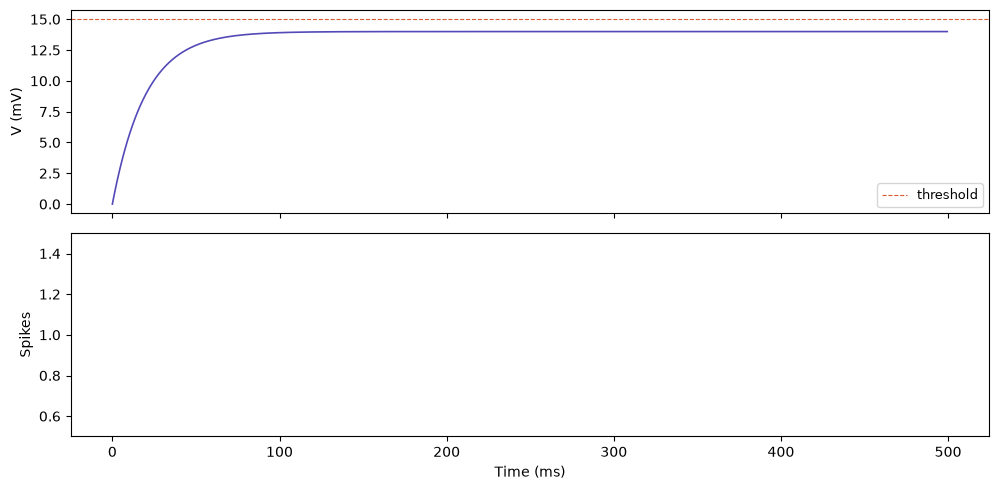

In [2]:
time_axis = np.arange(steps) * dt

fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(10, 5), sharex=True)

# Membrane potential
ax1.plot(time_axis, V, color='#534AB7', lw=1.2)
ax1.axhline(V_th, color='#D85A30', lw=0.8, linestyle='--', label='threshold')
ax1.set_ylabel('V (mV)')
ax1.legend(fontsize=9)

# Spike train (raster for one neuron)
spike_times = time_axis[spikes]
ax2.scatter(spike_times, np.ones_like(spike_times), 
            marker='|', color='#D85A30', s=100)
ax2.set_ylabel('Spikes')
ax2.set_xlabel('Time (ms)')
ax2.set_ylim(0.5, 1.5)

plt.tight_layout()
plt.show()

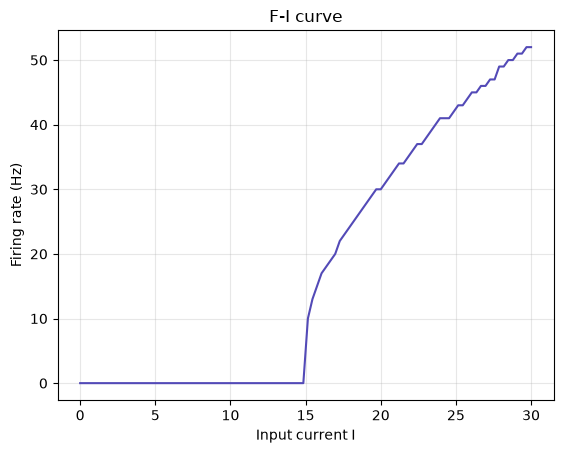

In [3]:
def simulate_lif(I_input, T=1000, dt=0.5, tau=20, V_th=15, V_reset=0, t_ref=5):
    steps = int(T / dt)
    V = 0.0
    ref_timer = 0.0
    spike_count = 0

    for t in range(steps):
        if ref_timer > 0:
            ref_timer -= dt
        else:
            V += (-V + I_input) / tau * dt
            if V >= V_th:
                spike_count += 1
                V = V_reset
                ref_timer = t_ref

    return spike_count / (T / 1000)  # convert to Hz

currents = np.linspace(0, 30, 100)
firing_rates = [simulate_lif(I) for I in currents]

plt.plot(currents, firing_rates, color='#534AB7', lw=1.5)
plt.xlabel('Input current I')
plt.ylabel('Firing rate (Hz)')
plt.title('F-I curve')
plt.grid(alpha=0.3)
plt.show()

In [4]:
N = 100    # number of neurons
steps = int(T / dt)

# Each neuron gets slightly different input current (adds variety)
I_pop = np.random.uniform(8, 20, size=N)

V_pop = np.zeros(N)
ref_timers = np.zeros(N)
spike_record = np.zeros((steps, N), dtype=bool)

for t in range(1, steps):
    # Which neurons are NOT in refractory?
    active = ref_timers <= 0

    # Update only active neurons — boolean indexing
    V_pop[active] += (-V_pop[active] + I_pop[active]) / tau * dt

    # Detect spikes (threshold crossing)
    fired = (V_pop >= V_th)
    spike_record[t] = fired

    # Reset fired neurons and start refractory timer
    V_pop[fired] = V_reset
    ref_timers[fired] = t_ref

    # Count down refractory timers
    ref_timers = np.maximum(0, ref_timers - dt)

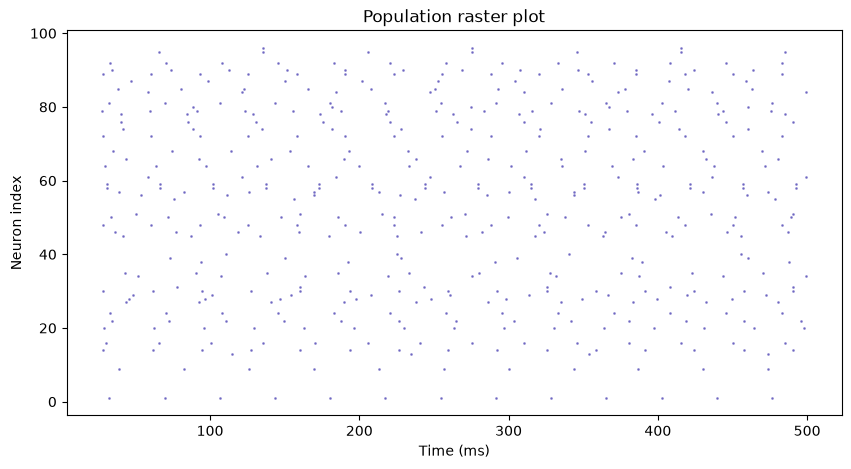

In [5]:
time_axis = np.arange(steps) * dt

plt.figure(figsize=(10, 5))
spike_times_idx, neuron_idx = np.where(spike_record)
plt.scatter(time_axis[spike_times_idx], neuron_idx, 
            s=1, color='#534AB7', alpha=0.6)
plt.xlabel('Time (ms)')
plt.ylabel('Neuron index')
plt.title('Population raster plot')
plt.show()